First, create a new conda environment named BI2025 and install the required packages from requirements.txt


In [1]:
#!conda create -n BI2025 python=3.11 -y
#!conda activate BI2025
#!pip install -r requirements.txt

In [2]:
# DO NOT MODIFY OR COPY THIS CELL!! 
# Note: The only imports allowed are Python's standard library, pandas, numpy, scipy, matplotlib, seaborn and scikit-learn
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import plotly.express as px
import datetime
import typing
import requests
import time
import shutil
import json
from starvers.starvers import TripleStoreEngine

## Graph-based documentation preliminaries

**!!!IMPORTANT!!!**

Everytime you work on this notebook, enter your student ID in the `executed_by` variable so that the cell executions are accredited to you.

In [3]:
executed_by ='stud-id_12412672'  # Replace the digits after "id_" with your own student ID

Set your group and student IDs. Do this only once.

In [4]:
# group id for this project
group_id = '061'  # Replace the digits with your group id

# Students working on this notebook
student_a = 'stud-id_12412672'  # Replace the digits after "id_" with student A's student ID
student_b = 'stud-id_76543210'  # Replace the digits after "id_" with student B's student ID

In [5]:
# Roles. Don't change these values.
code_writer_role = 'code_writer'
code_executor_role = 'code_executor'

Setup the starvers API for logging your steps into our server-sided graph database.

In [6]:
get_endpoint = "https://starvers.ec.tuwien.ac.at/BI2025"
post_endpoint = "https://starvers.ec.tuwien.ac.at/BI2025/statements"
engine = TripleStoreEngine(get_endpoint, post_endpoint, skip_connection_test=True)

Use these prefixes in your notebooks. You can extend this dict with your prefixes of additional ontologies that you use in this notebook. Replace 00 with your group id

In [7]:
prefixes = {
    'xsd': 'http://www.w3.org/2001/XMLSchema#',
    'rdfs': 'http://www.w3.org/2000/01/rdf-schema#',
    'foaf': 'http://xmlns.com/foaf/0.1/',
    'prov': 'http://www.w3.org/ns/prov#',
    'sc': 'https://schema.org/',
    'cr': 'http://mlcommons.org/croissant/',
    'mls': 'http://www.w3.org/ns/mls#',
    'mlso': 'http://w3id.org/mlso',
    'siu': 'https://si-digital-framework.org/SI/units/',
    'siq': 'https://si-digital-framework.org/SI/quantities/',
    'qudt': 'http://qudt.org/schema/qudt/',
    '': f'https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/',
}

prefix_header = '\n'.join([f'PREFIX {k}: <{v}>' for k, v in prefixes.items()]) + '\n\n'

Ontologies to use
* Provenance of the experiment process
    * PROV-O: 
        * doc: https://www.w3.org/TR/prov-o/
        * serialization: https://www.w3.org/ns/prov-o
* Data used and created
    * schema.org - Dataset: 
        * doc: https://schema.org/Dataset
        * serialization: https://schema.org/version/latest/schemaorg-current-https.ttl
    * Crossaint
        * doc: https://docs.mlcommons.org/croissant/docs/croissant-spec.html
        * serialization: https://github.com/mlcommons/croissant/blob/main/docs/croissant.ttl
* ML experiments performed
    * MLSO: 
        * doc: https://github.com/dtai-kg/MLSO
        * doc: https://dtai-kg.github.io/MLSO/#http://w3id.org/
        * serialization: https://dtai-kg.github.io/MLSO/ontology.ttl
* Measurements, Metrics, Units
    * QUDT
        * doc:https://qudt.org/
        * doc: https://github.com/qudt/qudt-public-repo
        * serialization: https://github.com/qudt/qudt-public-repo/blob/main/src/main/rdf/schema/SCHEMA_QUDT.ttl
    * SI Digital Framework
        * doc: https://github.com/TheBIPM/SI_Digital_Framework/blob/main/SI_Reference_Point/docs/README.md
        * doc: https://si-digital-framework.org/
        * doc: https://si-digital-framework.org/SI
        * serialization: https://github.com/TheBIPM/SI_Digital_Framework/blob/main/SI_Reference_Point/TTL/si.ttl
    * Quantities and Units
        * doc: https://www.omg.org/spec/Commons
        * serialization: https://www.omg.org/spec/Commons/QuantitiesAndUnits.ttl

Use this function to record execution times.

In [8]:
def now() -> str:
    """
    Returns the current time in ISO 8601 format with UTC timezone in the following format:
    YYYY-MM-DDTHH:MM:SS.sssZ
    """
    timestamp = datetime.datetime.now(datetime.timezone.utc)
    timestamp_formated = timestamp.strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3]  +"Z"

    return timestamp_formated

Register yourself in the Knowledge Graph using ProvO. Change the given name, family name and immatriculation number to reflect your own data.

In [9]:
# Ontologies used: foaf, prov, IAO
reigstration_triples_a = [
f':{student_a} rdf:type foaf:Person .',
f':{student_a} rdf:type prov:Agent .',
f':{student_a} foaf:givenName "Tim" .',
f':{student_a} foaf:familyName "Greß" .',
f':{student_a} <http://vivoweb.org/ontology/core#identifier> :{student_a} .',
f':{student_a} rdf:type <http://purl.obolibrary.org/obo/IAO_0000578> .',
f':{student_a} <http://www.w3.org/2000/01/rdf-schema#label> "Immatriculation number" .',
f':{student_a} <http://purl.obolibrary.org/obo/IAO_0000219> "12412672"^^xsd:string .',
]

reigstration_triples_b = [
f':{student_b} rdf:type foaf:Person .',
f':{student_b} rdf:type prov:Agent .',
f':{student_b} foaf:givenName "Morgan" .',
f':{student_b} foaf:familyName "Stern" .',
f':{student_b} <http://vivoweb.org/ontology/core#identifier> :{student_b} .',
f':{student_b} rdf:type <http://purl.obolibrary.org/obo/IAO_0000578> .',
f':{student_b} <http://www.w3.org/2000/01/rdf-schema#label> "Immatriculation number" .',
f':{student_b} <http://purl.obolibrary.org/obo/IAO_0000219> "76543210"^^xsd:string .',
]

role_triples = [
    f':{code_writer_role} rdf:type prov:Role .',
    f':{code_executor_role} rdf:type prov:Role .',
]


engine.insert(reigstration_triples_a, prefixes=prefixes)
engine.insert(reigstration_triples_b, prefixes=prefixes)
engine.insert(role_triples, prefixes=prefixes)

**What not do do**

Do not use [blank nodes](https://www.w3.org/wiki/BlankNodes).

PROV-O uses blank nodes to connect multiple elements with each other.
Such blank nodes (such as _:association) should not be used.
Instead, assign a fixed node ID such as
:5119fcd7-b571-41e0-9464-a37c7be0f574 by generating them outside of the
notebook.
We suggest that, for each setting where such a blank node is needed to
connect multiple elements, you create a unique hash (using uuid.uuid4())
and keep this as hard-coded identifier for the blank node. The template
notebook contains examples of this. Do *not* use these provided values,
as otherwise, your provenance documentations will all be connected via
these identifiers!
Also, do not generate them dynamically in every cell execution, e.g. by
using uuid.uuid4() in a cell. This would generate many new linking nodes
for connecting the same elements.
Compute one for each node (cell) where you need them and make sure to
use the same one on each re-execution of the notebook.

In [10]:
weather_data_path = os.path.join("data", "datasets", "weather")
cyclists_data_path = os.path.join("data", "datasets", "cyclists")

## Business Understanding 

In [11]:
## Each Activity that follows is part of the Business Understanding Phase

business_understanding_phase_executor = [
f':business_understanding_phase rdf:type prov:Activity .',
f':business_understanding_phase rdfs:label "Business Understanding Phase" .', ## Phase 1: Business Understanding
]
engine.insert(business_understanding_phase_executor, prefixes=prefixes)


In [12]:
#############################################
# Documentation
#############################################

data_src_and_scenario_comment = """
We use the "NBA Players" dataset from Kaggle (https://www.kaggle.com/datasets/justinas/nba-players-data) provided by Justinas Cirtuatas. It contains one row per player per season for 
the NBA seasons from 1996 to 2022. It includes biographical attributes, biometric attributes and basic box score statistics such as games played, average number of points or assists.

In the scenario we assume that the analytics department of an NBA team wants to have decision support for player acquisitions for the next season. 
The team wants to estimate how impactful a player will be in a season, capture by net_rating which is the difference of points scored and points allowed per 100 possessions 
when the player is on the court. The historical data will be used to build a model which helps to identify players that are undervalued
and helps to avoid signing player with low expected impact.  """

business_objectives_comment = """
1. Identify players that are undervalued in terms of their expected impact on the team's performance for the next season.
2. Avoid signing players with low expected impact to optimize the teams performance and transfer budget utilization.
3. Assist subjective scouting with a quantitative model and make the decisions more interpretable and reproducable.
"""

business_success_criteria_comment = """
1. On the training data at least 70% of the top 25% players by net_rating should be correctly identified as top 25% players by the model.
2. In the top 25% predicted by the model at least 80% of the players should be above the league average net_rating in their next season. 
3. In total the model should reduce the impact of bad signings (players with net_rating below league average) by at least 25% compared to random or 
subjective signings.
"""

data_mining_goals_comment = """
...
"""

data_mining_success_criteria_comment = """
...
"""

ai_risk_aspects_comment = """
...
"""


bu_ass_uuid_executor = "bb6a40f9-9d92-4f9f-bbd2-b65ef6a82da2" # Generate once
business_understanding_executor = [
f':business_understanding rdf:type prov:Activity .',
f':business_understanding sc:isPartOf :business_understanding_phase .', # Connect Activity to Parent Business Understanding Phase Activity
f':business_understanding prov:qualifiedAssociation :{bu_ass_uuid_executor} .',
f':{bu_ass_uuid_executor} prov:agent :{executed_by} .',
f':{bu_ass_uuid_executor} rdf:type prov:Association .',
f':{bu_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(business_understanding_executor, prefixes=prefixes)


business_understanding_data_executor = [
# 1a
f':bu_data_source_and_scenario rdf:type prov:Entity .',
f':bu_data_source_and_scenario prov:wasGeneratedBy :business_understanding .',
f':bu_data_source_and_scenario rdfs:label "1a Data Source and Scenario" .',
f':bu_data_source_and_scenario rdfs:comment """{data_src_and_scenario_comment}""" .',
# 1b
f':bu_business_objectives rdf:type prov:Entity .',
f':bu_business_objectives prov:wasGeneratedBy :business_understanding .',
f':bu_business_objectives rdfs:label "1b Business Objectives" .',
f':bu_business_objectives rdfs:comment """{business_objectives_comment}""" .',
# 1c
f':bu_business_success_criteria rdf:type prov:Entity .',
f':bu_business_success_criteria prov:wasGeneratedBy :business_understanding .',
f':bu_business_success_criteria rdfs:label "1c Business Success Criteria" .',
f':bu_business_success_criteria rdfs:comment """{business_success_criteria_comment}""" .',
# 1d
f':bu_data_mining_goals rdf:type prov:Entity .',
f':bu_data_mining_goals prov:wasGeneratedBy :business_understanding .',
f':bu_data_mining_goals rdfs:label "1d Data Mining Goals" .',
f':bu_data_mining_goals rdfs:comment """{data_mining_goals_comment}""" .',
# 1e
f':bu_data_mining_success_criteria rdf:type prov:Entity .',
f':bu_data_mining_success_criteria prov:wasGeneratedBy :business_understanding .',
f':bu_data_mining_success_criteria rdfs:label "1e Data Mining Success Criteria" .',
f':bu_data_mining_success_criteria rdfs:comment """{data_mining_success_criteria_comment}""" .',
# 1f
f':bu_ai_risk_aspects rdf:type prov:Entity .',
f':bu_ai_risk_aspects prov:wasGeneratedBy :business_understanding .',
f':bu_ai_risk_aspects rdfs:label "1f AI risk aspects" .',
f':bu_ai_risk_aspects rdfs:comment """{ai_risk_aspects_comment}""" .',

]
engine.insert(business_understanding_data_executor, prefixes=prefixes)

## Data Understanding

The following pseudo-code & pseudo-documentation may be used as a hint.

In [13]:
## Each Activity that follows is part of the Data Understanding Phase

business_understanding_phase_executor = [
f':data_understanding_phase rdf:type prov:Activity .',
f':data_understanding_phase rdfs:label "Data Understanding Phase" .', 
]
engine.insert(business_understanding_phase_executor, prefixes=prefixes)


In [ ]:
nba_data_path = os.path.join("data", "all_seasons.csv")
load_nba_data_code_writer = student_a

def load_nba_data()-> pd.DataFrame:
    
    input_file = nba_data_path
    raw_data = pd.read_csv(input_file,  sep=',', header = 0)
    return raw_data

start_time_ld = now()
data = load_nba_data()   # 'data' is our main working DataFrame
end_time_ld = now()

#############################################
# Documentation
#############################################

# Now document the raw data and the loaded data using appropriate ontologies.

# Always add these triples for every activity to define the executor!
ld_ass_uuid_executor = "b8bac193-c4e6-4e31-9134-b23e001e279c" # Generate once
load_nba_data_executor = [
    f':load_nba_data prov:qualifiedAssociation :{ld_ass_uuid_executor} .',
    f':{ld_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{ld_ass_uuid_executor} rdf:type prov:Association .',
    f':{ld_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(load_nba_data_executor, prefixes=prefixes)

ld_ass_uuid_writer = "c600e15c-87a9-4e2a-be85-b6c2a3014210" # Generate once
ld_report = """
Load all NBA player-seasons data and create the DataFrame. 
"""
load_nba_data_activity = [
    ':load_nba_data rdf:type prov:Activity .',
    ':load_nba_data sc:isPartOf :data_understanding_phase .',
    ':load_nba_data rdfs:comment \'Data Understanding\' .',
    f':load_nba_data rdfs:comment """{ld_report}""" .', 
    f':load_nba_data prov:startedAtTime "{start_time_ld}"^^xsd:dateTime .',
    f':load_nba_data prov:endedAtTime "{end_time_ld}"^^xsd:dateTime .',
    f':load_nba_data prov:qualifiedAssociation :{ld_ass_uuid_writer} .',
    f':{ld_ass_uuid_writer} prov:agent :{load_nba_data_code_writer} .',
    f':{ld_ass_uuid_writer} rdf:type prov:Association .',
    f':{ld_ass_uuid_writer} prov:hadRole :{code_writer_role} .',
  
    # INPUT of activity
    ':load_nba_data prov:used :raw_data .',
    ':load_nba_data prov:used :raw_data_path .',
    ':raw_data rdf:type prov:Entity .',
    ':raw_data_path rdf:type prov:Entity .',
    ':raw_data prov:wasDerivedFrom :raw_data_path .',
    # OUTPUT of activity
    ':data rdf:type prov:Entity .',
    ':data prov:wasGeneratedBy :load_nba_data .',
    ':data prov:wasDerivedFrom :raw_data .',
]
engine.insert(load_nba_data_activity, prefixes=prefixes)

# Further descibe the raw data using Croissant
raw_data_triples = [


    ':raw_data rdf:type sc:Dataset .',
    ':raw_data sc:name "NBA players dataset" .',
    ':raw_data sc:description "Season-level NBA player data with biographical, biometric and statistical features for NBA players across multiple seasons." .',

    # File / distribution
    ':nba_csv rdf:type cr:FileObject .',
    ':nba_csv sc:name "all_seasons.csv" .',
    ':nba_csv sc:encodingFormat "text/csv" .',
    ':raw_data sc:distribution :nba_csv .',

    # RecordSet for the CSV table
    ':raw_recordset rdf:type cr:RecordSet .',
    ':raw_recordset sc:name "Table of NBA player seasons (raw CSV)" .',
    ':raw_recordset cr:source :nba_csv .',
    ':raw_data cr:recordSet :raw_recordset .'
    
    # Unnamed: 0 (index column)
    ':field_unnamed_0 rdf:type cr:Field .',
    ':field_unnamed_0 sc:name "Unnamed: 0" .',
    ':field_unnamed_0 sc:description "Original row index from the Kaggle CSV file." .',
    ':field_unnamed_0 cr:dataType xsd:integer .',
    ':raw_recordset cr:field :field_unnamed_0 .',

    # player_name
    ':field_player_name rdf:type cr:Field .',
    ':field_player_name sc:name "player_name" .',
    ':field_player_name sc:description "Player full name." .',
    ':field_player_name cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_player_name .',

    # team_abbreviation
    ':field_team_abbreviation rdf:type cr:Field .',
    ':field_team_abbreviation sc:name "team_abbreviation" .',
    ':field_team_abbreviation sc:description "Abbreviation of the NBA team for that season (e.g. LAL, BOS)." .',
    ':field_team_abbreviation cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_team_abbreviation .',

    # age
    ':field_age rdf:type cr:Field .',
    ':field_age sc:name "age" .',
    ':field_age sc:description "Player age in years during the given season." .',
    ':field_age cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_age .',

    # player_height
    ':field_player_height rdf:type cr:Field .',
    ':field_player_height sc:name "player_height" .',
    ':field_player_height sc:description "Player height (in centimetres)." .',
    ':field_player_height cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_player_height .',

    # player_weight
    ':field_player_weight rdf:type cr:Field .',
    ':field_player_weight sc:name "player_weight" .',
    ':field_player_weight sc:description "Player weight (in kg)." .',
    ':field_player_weight cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_player_weight .',

    # college
    ':field_college rdf:type cr:Field .',
    ':field_college sc:name "college" .',
    ':field_college sc:description "College or university the player attended." .',
    ':field_college cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_college .',

    # country
    ':field_country rdf:type cr:Field .',
    ':field_country sc:name "country" .',
    ':field_country sc:description "Country associated with the player (typically nationality)." .',
    ':field_country cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_country .',

    # draft_year
    ':field_draft_year rdf:type cr:Field .',
    ':field_draft_year sc:name "draft_year" .',
    ':field_draft_year sc:description "Year the player was drafted, or a string such as Undrafted if not applicable." .',
    ':field_draft_year cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_draft_year .',

    # draft_round
    ':field_draft_round rdf:type cr:Field .',
    ':field_draft_round sc:name "draft_round" .',
    ':field_draft_round sc:description "Draft round in which the player was selected, or a code if not drafted." .',
    ':field_draft_round cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_draft_round .',

    # draft_number
    ':field_draft_number rdf:type cr:Field .',
    ':field_draft_number sc:name "draft_number" .',
    ':field_draft_number sc:description "Overall draft pick number, or a value for undrafted players." .',
    ':field_draft_number cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_draft_number .',

    # gp
    ':field_gp rdf:type cr:Field .',
    ':field_gp sc:name "gp" .',
    ':field_gp sc:description "Games played by the player in that season." .',
    ':field_gp cr:dataType xsd:integer .',
    ':raw_recordset cr:field :field_gp .',

    # pts
    ':field_pts rdf:type cr:Field .',
    ':field_pts sc:name "pts" .',
    ':field_pts sc:description "Points per game in that season." .',
    ':field_pts cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_pts .',

    # reb
    ':field_reb rdf:type cr:Field .',
    ':field_reb sc:name "reb" .',
    ':field_reb sc:description "Rebounds per game in that season." .',
    ':field_reb cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_reb .',

    # ast
    ':field_ast rdf:type cr:Field .',
    ':field_ast sc:name "ast" .',
    ':field_ast sc:description "Assists per game in that season." .',
    ':field_ast cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_ast .',

    # net_rating
    ':field_net_rating rdf:type cr:Field .',
    ':field_net_rating sc:name "net_rating" .',
    ':field_net_rating sc:description "Net rating for the player (offensive rating minus defensive rating) in that season." .',
    ':field_net_rating cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_net_rating .',

    # oreb_pct
    ':field_oreb_pct rdf:type cr:Field .',
    ':field_oreb_pct sc:name "oreb_pct" .',
    ':field_oreb_pct sc:description "Offensive rebound percentage for the player." .',
    ':field_oreb_pct cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_oreb_pct .',

    # dreb_pct
    ':field_dreb_pct rdf:type cr:Field .',
    ':field_dreb_pct sc:name "dreb_pct" .',
    ':field_dreb_pct sc:description "Defensive rebound percentage for the player." .',
    ':field_dreb_pct cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_dreb_pct .',

    # usg_pct
    ':field_usg_pct rdf:type cr:Field .',
    ':field_usg_pct sc:name "usg_pct" .',
    ':field_usg_pct sc:description "Usage percentage: estimate of the team plays used by the player while on the floor." .',
    ':field_usg_pct cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_usg_pct .',

    # ts_pct
    ':field_ts_pct rdf:type cr:Field .',
    ':field_ts_pct sc:name "ts_pct" .',
    ':field_ts_pct sc:description "True shooting percentage for the player in that season." .',
    ':field_ts_pct cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_ts_pct .',

    # ast_pct
    ':field_ast_pct rdf:type cr:Field .',
    ':field_ast_pct sc:name "ast_pct" .',
    ':field_ast_pct sc:description "Assist percentage: estimate of teammate field goals assisted by the player." .',
    ':field_ast_pct cr:dataType xsd:double .',
    ':raw_recordset cr:field :field_ast_pct .',

    # season
    ':field_season rdf:type cr:Field .',
    ':field_season sc:name "season" .',
    ':field_season sc:description "Season identifier (e.g. 1996-97, 2019-20)." .',
    ':field_season cr:dataType xsd:string .',
    ':raw_recordset cr:field :field_season .',
]

engine.insert(raw_data_triples, prefixes=prefixes)

# Also the output of the load activity is a dataset that can be described with Croissant
data_triples = [
    ':data rdf:type sc:Dataset .',
    ':data sc:name "Loaded NBA player seasons DataFrame" .',
    ':data sc:description "Dataframe of NBA player seasons data." .',
    
    ':recordset rdf:type cr:RecordSet .',
    ':recordset sc:name "Loaded NBA player seasons table" .',
    ':data cr:recordSet :recordset .',

    ':recordset cr:field :field_unnamed_0 .',
    ':recordset cr:field :field_player_name .',
    ':recordset cr:field :field_team_abbreviation .',
    ':recordset cr:field :field_age .',
    ':recordset cr:field :field_player_height .',
    ':recordset cr:field :field_player_weight .',
    ':recordset cr:field :field_college .',
    ':recordset cr:field :field_country .',
    ':recordset cr:field :field_draft_year .',
    ':recordset cr:field :field_draft_round .',
    ':recordset cr:field :field_draft_number .',
    ':recordset cr:field :field_gp .',
    ':recordset cr:field :field_pts .',
    ':recordset cr:field :field_reb .',
    ':recordset cr:field :field_ast .',
    ':recordset cr:field :field_net_rating .',
    ':recordset cr:field :field_oreb_pct .',
    ':recordset cr:field :field_dreb_pct .',
    ':recordset cr:field :field_usg_pct .',
    ':recordset cr:field :field_ts_pct .',
    ':recordset cr:field :field_ast_pct .',
    ':recordset cr:field :field_season .',
]
engine.insert(data_triples, prefixes=prefixes)

# Also add the units to the fields
units_triples = [
    ':field_gp qudt:unit qudt:CountingUnit .',

    ':field_pts qudt:unit qudt:DimensionlessUnit .',
    ':field_reb qudt:unit qudt:DimensionlessUnit .',
    ':field_ast qudt:unit qudt:DimensionlessUnit .',

    ':field_net_rating qudt:unit qudt:DimensionlessUnit .',
    ':field_oreb_pct qudt:unit qudt:DimensionlessUnit .',
    ':field_dreb_pct qudt:unit qudt:DimensionlessUnit .',
    ':field_usg_pct qudt:unit qudt:DimensionlessUnit .',
    ':field_ts_pct qudt:unit qudt:DimensionlessUnit .',
    ':field_ast_pct qudt:unit qudt:DimensionlessUnit .',

    ':field_age qudt:unit qudt:DimensionlessUnit .',
]


engine.insert(units_triples, prefixes=prefixes)

In [23]:
summarize_nba_data_code_writer = student_a
def summarize_nba_data(df: pd.DataFrame) -> dict:
    """
    Here we just want to get a basic understanding of our dataset for further steps 
    """
    n_rows, n_cols = df.shape
    missing = df.isna().sum()
    column_types = df.dtypes.astype(str)

    
    print("=== NBA dataset overview ===")
    print(f"Rows: {n_rows}, Columns: {n_cols}")
    print("\nColumn types:")
    print(column_types)
    print("\nMissing values (top 10):")
    print(missing.sort_values(ascending=False).head(10))

    report = {
        "n_rows": int(n_rows),
        "n_columns": int(n_cols),
        "column_types": column_types.to_dict(),
        "missing_counts": missing.to_dict(),
    }
    return report

start_time_du = now()
du_report = summarize_nba_data(data)
end_time_du = now()

du_ass_uuid_executor = "e9b3c093-7c9b-4a9f-9b0e-0c7c6e0efb41"  
summarize_nba_data_executor = [
    f':summarize_nba_data prov:qualifiedAssociation :{du_ass_uuid_executor} .',
    f':{du_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{du_ass_uuid_executor} rdf:type prov:Association .',
    f':{du_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(summarize_nba_data_executor, prefixes=prefixes)

du_ass_uuid_writer = "5c37e4b6-a3dc-4f4a-8f07-9d31686b6d0b"  # Generate once and keep
du_comment = """
Here we just inspect the NBA dataset for basic measures to get an overview of the data we have. 
"""

summarize_nba_data_activity = [
    # Activity itself
    ':summarize_nba_data rdf:type prov:Activity .',
    ':summarize_nba_data sc:isPartOf :data_understanding_phase .',
    ":summarize_nba_data rdfs:comment 'Data Understanding' .",
    f':summarize_nba_data rdfs:comment """{du_comment}""" .',
    f':summarize_nba_data prov:startedAtTime "{start_time_du}"^^xsd:dateTime .',
    f':summarize_nba_data prov:endedAtTime "{end_time_du}"^^xsd:dateTime .',

    #Code writer role
    f':summarize_nba_data prov:qualifiedAssociation :{du_ass_uuid_writer} .',
    f':{du_ass_uuid_writer} prov:agent :{summarize_nba_data_code_writer} .',
    f':{du_ass_uuid_writer} rdf:type prov:Association .',
    f':{du_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    #Input
    ':summarize_nba_data prov:used :data .',

    # Output entity: overview report
    ':du_overview rdf:type prov:Entity .',
    ':du_overview rdfs:label "Data Understanding: basic NBA dataset overview" .',
    f':du_overview rdfs:comment """{json.dumps(du_report, indent=2)}""" .',
    ':du_overview prov:wasGeneratedBy :summarize_nba_data .',
]
engine.insert(summarize_nba_data_activity, prefixes=prefixes)


=== NBA dataset overview ===
Rows: 12844, Columns: 22

Column types:
Unnamed: 0             int64
player_name           object
team_abbreviation     object
age                  float64
player_height        float64
player_weight        float64
college               object
country               object
draft_year            object
draft_round           object
draft_number          object
gp                     int64
pts                  float64
reb                  float64
ast                  float64
net_rating           float64
oreb_pct             float64
dreb_pct             float64
usg_pct              float64
ts_pct               float64
ast_pct              float64
season                object
dtype: object

Missing values (top 10):
college              1854
Unnamed: 0              0
team_abbreviation       0
age                     0
player_height           0
player_name             0
player_weight           0
country                 0
draft_year              0
draft_round        

Numeric distributions
age             | mean=27.05, std=4.34, min=18.00, max=44.00, outliers(IQR)=47
player_height   | mean=200.56, std=9.11, min=160.02, max=231.14, outliers(IQR)=19
player_weight   | mean=100.26, std=12.43, min=60.33, max=163.29, outliers(IQR)=57
gp              | mean=51.15, std=25.08, min=1.00, max=85.00, outliers(IQR)=0
pts             | mean=8.21, std=6.02, min=0.00, max=36.10, outliers(IQR)=298
reb             | mean=3.56, std=2.48, min=0.00, max=16.30, outliers(IQR)=524
ast             | mean=1.82, std=1.80, min=0.00, max=11.70, outliers(IQR)=841
net_rating      | mean=-2.23, std=12.67, min=-250.00, max=300.00, outliers(IQR)=622
oreb_pct        | mean=0.05, std=0.04, min=0.00, max=1.00, outliers(IQR)=76
dreb_pct        | mean=0.14, std=0.06, min=0.00, max=1.00, outliers(IQR)=137
usg_pct         | mean=0.18, std=0.05, min=0.00, max=1.00, outliers(IQR)=210
ts_pct          | mean=0.51, std=0.10, min=0.00, max=1.50, outliers(IQR)=842
ast_pct         | mean=0.13, std

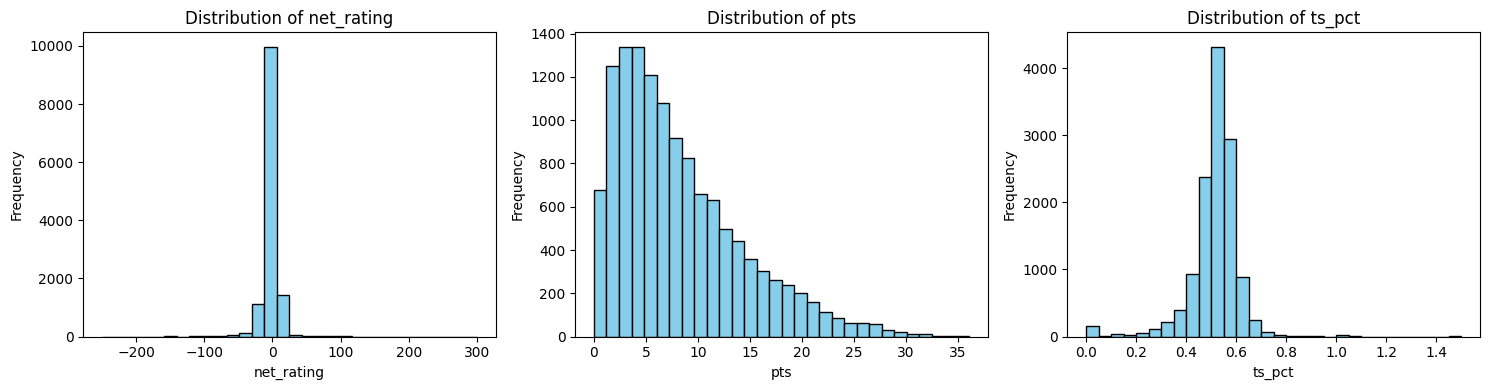

In [ ]:
check_distribution_code_writer = student_a

def check_distribution(df: pd.DataFrame) -> dict:
    """
    Here we inspect the distribution of our numeric values and check outliers with simple IQR 
    """
    numeric_cols = [
        "age",
        "player_height",
        "player_weight",
        "gp",
        "pts",
        "reb",
        "ast",
        "net_rating",
        "oreb_pct",
        "dreb_pct",
        "usg_pct",
        "ts_pct",
        "ast_pct",
    ]

    distribution_report = {}

    for col in numeric_cols:
        s = pd.to_numeric(df[col], errors='coerce')
        q = s.quantile([0.05, 0.25, 0.5, 0.75, 0.95])
        q05 = float(q.loc[0.05])
        q25 = float(q.loc[0.25])
        q50 = float(q.loc[0.5])
        q75 = float(q.loc[0.75])
        q95 = float(q.loc[0.95])
        iqr = q75 - q25

        lower = q25 - 1.5 * iqr
        upper = q75 + 1.5 * iqr
        n_outliers = int(((s < lower) | (s > upper)).sum())

        distribution_report[col] = {
            "count": int(s.shape[0]),
            "mean": float(s.mean()),
            "std": float(s.std(ddof=1)),
            "min": float(s.min()),
            "max": float(s.max()),
            "q05": q05,
            "q25": q25,
            "median": q50,
            "q75": q75,
            "q95": q95,
            "iqr": iqr,
            "lower_iqr_bound": float(lower),
            "upper_iqr_bound": float(upper),
            "n_outliers_iqr": n_outliers,
        }

    print("Numeric distributions")
    for col, stats in distribution_report.items():
        print(
            f"{col:15s} | mean={stats['mean']:.2f}, std={stats['std']:.2f}, "
            f"min={stats['min']:.2f}, max={stats['max']:.2f}, "
            f"outliers(IQR)={stats['n_outliers_iqr']}"
        )

    #we also want to plot some distributions, lets look at the ones that seem the most important
    cols_for_plot = ["net_rating","pts", "ts_pct"]
    cols_for_plot = [c for c in cols_for_plot if c in df.columns]

    if cols_for_plot:
        fig, axes = plt.subplots(1, len(cols_for_plot), figsize=(5 * len(cols_for_plot), 4))
        if len(cols_for_plot) == 1:
            axes = [axes]
        for ax, col in zip(axes, cols_for_plot):
            ax.hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
            ax.set_title(f'Distribution of {col}')
            ax.set_xlabel(col)
            ax.set_ylabel('Frequency')
        plt.tight_layout()
        plt.show()
        return {"per_column": distribution_report}


start_time_dist = now()
dist_report = check_distribution(data)
end_time_dist = now()

dist_ass_uuid_executor = "f2e3aa1b-fb16-4f32-8d0f-28f0f4a4d3f1"  # generate once and keep
check_distribution_executor = [
    f':check_distribution prov:qualifiedAssociation :{dist_ass_uuid_executor} .',
    f':{dist_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{dist_ass_uuid_executor} rdf:type prov:Association .',
    f':{dist_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(check_distribution_executor, prefixes=prefixes)

dist_ass_uuid_writer = "9b4b12a6-4aad-4c5c-9f4f-4c0d7e6a8f2e"  # generate once and keep
dist_comment = """
Here we inspect the distributions and plausible value ranges for the numeric NBA features by computing summary statistics for all of them
and by computing and IQR-based outlier range and count how many of the values fall out of this range. We also create some histograms 
for the most important attributes for visualization.
"""

check_distribution_activity = [
    # Activity node
    ':check_distribution rdf:type prov:Activity .',
    ':check_distribution sc:isPartOf :data_understanding_phase .',
    ":check_distribution rdfs:comment 'Data Understanding' .",
    f':check_distribution rdfs:comment """{dist_comment}""" .',
    f':check_distribution prov:startedAtTime "{start_time_dist}"^^xsd:dateTime .',
    f':check_distribution prov:endedAtTime "{end_time_dist}"^^xsd:dateTime .',

    # Code writer association
    f':check_distribution prov:qualifiedAssociation :{dist_ass_uuid_writer} .',
    f':{dist_ass_uuid_writer} prov:agent :{check_distribution_code_writer} .',
    f':{dist_ass_uuid_writer} rdf:type prov:Association .',
    f':{dist_ass_uuid_writer} prov:hadRole :{code_writer_role} .',

    # Input
    ':check_distribution prov:used :data .',

    # Output entity: numeric stats report
    ':du_numeric_stats rdf:type prov:Entity .',
    ':du_numeric_stats rdfs:label "Data Understanding: numeric distribution summary" .',
    f':du_numeric_stats rdfs:comment """{json.dumps(dist_report, indent=2)}""" .',
    ':du_numeric_stats prov:wasGeneratedBy :check_distribution .',
]

engine.insert(check_distribution_activity, prefixes=prefixes)

**Continue with other tasks of the Data Understanding phase such as checking the distribution, skewness, plausibility of values, etc...**

## Data Preparation

In [ ]:
## Each Activity that follows is part of the Data Preparation Phase

data_preparation_phase_executor = [
f':data_preparation_phase rdf:type prov:Activity .',
f':data_preparation_phase rdfs:label "Data Preparation Phase" .', 
]
engine.insert(data_preparation_phase_executor, prefixes=prefixes)

In [ ]:
handle_outliers_code_writer = student_b
def handle_outliers(df:pd.DataFrame, outliers_report: dict) -> pd.DataFrame:
    # REMOVE OUTLIERS
    return df

start_time_td = now()
handle_outliers(data, outliers_report)
end_time_td = now()

#############################################
# Documentation
#############################################
# This is the continuation of the example from the Data Understanding phase above.
# There are three steps involved in this process:
# 1. activity creates a figure, report etc. => already done in data understanding phase
# 2. activity inspects the outcome and derives decisions => already done in data understanding phase
# 3. activity follows up on the decision by changing the data => in this case by removing the the outliers that were found

ro_ass_uuid_executor = "ec7e81e1-86ea-475a-a8d4-c7d8ee535488"
handle_outliers_executor = [
    f':handle_outliers prov:qualifiedAssociation :{ro_ass_uuid_executor} .',
    f':{ro_ass_uuid_executor} prov:agent :{executed_by} .',
    f':{ro_ass_uuid_executor} rdf:type prov:Association .',
    f':{ro_ass_uuid_executor} prov:hadRole :{code_executor_role} .',
]
engine.insert(handle_outliers_executor, prefixes=prefixes)

td_ass_uuid_writer = "1405f15a-3545-4014-a962-637f3c10a137"
td_comment = """
Removing all outliers that were identifying in the Data Understanding Phase.
"""
handle_outliers_activity = [
    ':handle_outliers rdf:type prov:Activity .',
    ':handle_outliers sc:isPartOf :data_preparation_phase .',
    ':handle_outliers rdfs:comment \'Data Preparation\' .', 
    f':handle_outliers rdfs:comment """{td_comment}""" .', 
    f':handle_outliers prov:startedAtTime "{start_time_td}"^^xsd:dateTime .',
    f':handle_outliers prov:endedAtTime "{end_time_td}"^^xsd:dateTime .',
    f':handle_outliers prov:qualifiedAssociation :{td_ass_uuid_writer} .',
    f':{td_ass_uuid_writer} prov:agent :{handle_outliers_code_writer} .',
    f':{td_ass_uuid_writer} rdf:type prov:Association .',
    f':{td_ass_uuid_writer} prov:hadRole :{code_writer_role} .',
    ':handle_outliers prov:used :data .',
    ':handle_outliers prov:used :outlier_decision .',
    ':cleaned_data rdf:type prov:Entity .',
    ':cleaned_data prov:wasGeneratedBy :handle_outliers .',
    ':cleaned_data prov:wasDerivedFrom :data .',
]
engine.insert(handle_outliers_activity, prefixes=prefixes)

**Continue with other tasks of the Data Preparation phase such as binning, scaling etc...**

In [ ]:
# Your final transformed dataset should also be documented appropriately using Croissant, SI, etc.

prepared_data_triples = [
    ':prepared_data rdf:type prov:Entity .',
    ':prepared_data prov:wasDerivedFrom :cleaned_data .',
    ':prepared_data rdf:type sc:Dataset .',
    # ....
]
engine.insert(prepared_data_triples, prefixes=prefixes)

## Modeling

In [ ]:
## Each Activity that follows is part of the Modeling Phase

modeling_phase_executor = [
f':modeling_phase rdf:type prov:Activity .',
f':modeling rdfs:label "Modeling Phase" .', 
]
engine.insert(modeling_phase_executor, prefixes=prefixes)


In [ ]:
model_data_code_writer = student_a

#############################################
# Documentation 4a
#############################################

dma_ass_uuid_writer = "b3e840ab-ac23-415e-bd9c-6d00bb79c37a"
dma_comment = """
...
"""

identify_data_mining_algorithm_activity = [
    f':define_algorithm rdf:type prov:Activity .',
    f':define_algorithm sc:isPartOf :modeling_phase .',
    f':define_algorithm rdfs:comment """{dma_comment}""" .',
    f':define_algorithm prov:qualifiedAssociation :{dma_ass_uuid_writer} .',
    f':{dma_ass_uuid_writer} prov:agent :{model_data_code_writer} .',
    f':{dma_ass_uuid_writer} rdf:type prov:Association .',
    f':{dma_ass_uuid_writer} prov:hadRole :{code_writer_role} .',
    
    # example algorithm definition
    f':random_forest_algorithm rdf:type mls:Algorithm .',
    f':random_forest_algorithm rdfs:label "Random Forest Algorithm" .',

    # example implementation
    f':random_forrest_classifier_implementation rdf:type mls:Implementation .',
    f':random_forrest_classifier_implementation rdfs:label "Scikit-learn RandomForestClassifier" .',
    f':random_forrest_classifier_implementation mls:implements :random_forest_algorithm .',
    f':random_forrest_classifier_implementation prov:wasGeneratedBy :define_algorithm .',

    
    # you can also define your Evaluation Measures here
    
    # example evaluation 
    f':r2_score_measure rdf:type mls:EvaluationMeasure .',
    f':r2_score_measure rdfs:label "R-squared Score" .',
    f':r2_score_measure rdfs:comment "xxx" .',
    f':r2_score_measure prov:wasGeneratedBy :define_algorithm .',

    
]
engine.insert(identify_data_mining_algorithm_activity, prefixes=prefixes)

In [ ]:
#############################################
# Documentation 4b
#############################################

hp_ass_uuid_writer = "fff582a8-c5cd-4030-978b-9f56b603167c"
hp_comment = """
...
"""
identify_hp_activity = [
    f':identify_hyperparameters rdf:type prov:Activity .',
    f':identify_hyperparameters sc:isPartOf :modeling_phase .',
    f':identify_hyperparameters rdfs:comment """{hp_comment}""" .',
    f':identify_hyperparameters prov:qualifiedAssociation :{hp_ass_uuid_writer} .',
    f':{hp_ass_uuid_writer} prov:agent :{model_data_code_writer} .',
    f':{hp_ass_uuid_writer} rdf:type prov:Association .',
    f':{hp_ass_uuid_writer} prov:hadRole :{code_writer_role} .',
    
    # example parameter
    f':hp_learning_rate rdf:type mls:HyperParameter .',
    f':hp_learning_rate rdfs:label "Learning Rate" .',
    f':hp_learning_rate rdfs:comment "..." .',
    f':random_forrest_classifier_implementation mls:hasHyperParameter :hp_learning_rate .',
    f':hp_learning_rate prov:wasGeneratedBy :identify_hyperparameters .',

    # continue with your identified hyperparameters
    
]
engine.insert(identify_hp_activity, prefixes=prefixes)

In [ ]:
def split_data(df: pd.DataFrame):
    #do something
    return 'train_set', 'validation_set', 'test_set'

#############################################
# Documentation 4c
#############################################

### Define Train/Validation/Test splits
split_ass_uuid_writer = "fb58ae6c-9d58-44c9-ac7e-529111bdf7fc"
split_comment = """
...
"""
## Use your prepared dataset
input_dataset = ":prepared_data" 

define_split_activity = [
    f':define_data_split rdf:type prov:Activity .',
    f':define_data_split sc:isPartOf :modeling_phase .',
    f':define_data_split rdfs:comment "Train/Validation/Test Split Definition" .',
    f':define_data_split rdfs:comment """{split_comment}""" .',
    f':define_data_split prov:qualifiedAssociation :{split_ass_uuid_writer} .',
    f':{split_ass_uuid_writer} prov:agent :{model_data_code_writer} .',
    f':{split_ass_uuid_writer} rdf:type prov:Association .',
    f':{split_ass_uuid_writer} prov:hadRole :{code_writer_role} .',
    f':define_data_split prov:used {input_dataset} .',
    
    # Training Set
    f':training_set rdf:type sc:Dataset .',
    f':training_set rdfs:label "Training Set" .',
    f':training_set prov:wasGeneratedBy :define_data_split .',
    f':training_set prov:wasDerivedFrom {input_dataset} .',
    f':training_set rdfs:comment "Contains xx samples" .', 

    # Validation Set
    f':validation_set rdf:type sc:Dataset .',
    f':validation_set rdfs:label "Validation Set" .',
    f':validation_set prov:wasGeneratedBy :define_data_split .',
    f':validation_set prov:wasDerivedFrom {input_dataset} .',
    f':validation_set rdfs:comment "Contains xx samples" .', 

    # Test Set
    f':test_set rdf:type sc:Dataset .',
    f':test_set rdfs:label "Test Set" .',
    f':test_set prov:wasGeneratedBy :define_data_split .',
    f':test_set prov:wasDerivedFrom {input_dataset} .',
    f':test_set rdfs:comment "Contains xx samples" .', 

    
]
engine.insert(define_split_activity, prefixes=prefixes)

In [ ]:
def train_and_finetune_model(training_set, validation_set):
    # do something here

    # Try to automate as much documentation work as possible.
    # Define your training runs with their respective hyperparameter settings, etc.
    # Document each time a training run, model, its hp_settings, evaluations, ...  
    # Create performance figures/graphs

    return 'Find most suitable model'


start_time_tafm = now()
# train_and_finetune_model()
end_time_tafm = now() 


#############################################
# Documentation 4d & e & f
#############################################

tafm_ass_uuid_writer = "21d60fe3-c9ab-4a0a-bae7-b9fe9653c755"
tafm_comment = """
...
"""

# EXAMPLE output from your training
training_run1 = "run_1" 
model_run1 = "model_run1"
hp1_setting_run1 = "hp_setting_run1"
eval_train_run1 = "metric_train_run1"
eval_validation_run1 = "metric_validation_run1"


train_model_activity = [
    # Activity 
    f':train_and_finetune_model rdf:type prov:Activity .',
    f':train_and_finetune_model sc:isPartOf :modeling_phase .',
    f':train_and_finetune_model rdfs:comment """{tafm_comment}""" .',
    f':train_and_finetune_model prov:startedAtTime "{start_time_tafm}"^^xsd:dateTime .',
    f':train_and_finetune_model prov:endedAtTime "{end_time_tafm}"^^xsd:dateTime .',
    f':train_and_finetune_model prov:qualifiedAssociation :{tafm_ass_uuid_writer} .',
    f':{tafm_ass_uuid_writer} prov:agent :{model_data_code_writer} .',
    f':{tafm_ass_uuid_writer} rdf:type prov:Association .',
    f':{tafm_ass_uuid_writer} prov:hadRole :{code_writer_role} .',
    
    ########################################
    # ONE model run - automate everything below!

    # Parameter settings
    f':{hp1_setting_run1} rdf:type mls:HyperParameterSetting .',
    f':{hp1_setting_run1} mls:specifiedBy :hp_learning_rate .',
    f':{hp1_setting_run1} mls:hasValue "1.23"^^xsd:double .',
    f':{hp1_setting_run1} prov:wasGeneratedBy :train_and_finetune_model .',
    # add your further parameters

    # Describe your Run
    f':{training_run1} rdf:type mls:Run .',
    f':{training_run1} sc:isPartOf :train_and_finetune_model .',
    f':{training_run1} mls:realizes :random_forest_algorithm .',
    f':{training_run1} rdf:label "Training Run 1 with..." .',
    f':{training_run1} mls:executes :your_implementation .', 
    f':{training_run1} mls:hasInput :training_set .',
    f':{training_run1} mls:hasInput :validation_set .',
    f':{training_run1} mls:hasInput :{hp1_setting_run1} .',     
    # list all your used parameters here
    f':{training_run1} mls:hasOutput :{model_run1} .',
    f':{training_run1} mls:hasOutput :{eval_train_run1} .',
    f':{training_run1} mls:hasOutput :{eval_validation_run1} .',

    # Describe your Model
    f':{model_run1} rdf:type mls:Model .',
    f':{model_run1} prov:label "xxx" .',
    f':{model_run1} prov:wasGeneratedBy :{training_run1} .',
    f':{model_run1} mlso:trainedOn :training_set .',
    f':{model_run1} mlso:hasAlgorithmType :random_forest_algorithm .',

    # Describe your evaluations
    # You can have multiple evaluations per model 
    f':{eval_train_run1} rdf:type mls:ModelEvaluation .',
    f':{eval_train_run1} prov:wasGeneratedBy :{training_run1} .',
    f':{eval_train_run1} mls:hasValue "1.23"^^xsd:double .',
    f':{eval_train_run1} mls:specifiedBy :r2_score_measure .',
    f':{eval_train_run1} prov:used :training_set .',

    f':{eval_validation_run1} rdf:type mls:ModelEvaluation .',
    f':{eval_validation_run1} prov:wasGeneratedBy :{training_run1} .',
    f':{eval_validation_run1} mls:hasValue "1.23"^^xsd:double .',
    f':{eval_validation_run1} mls:specifiedBy :r2_score_measure .',
    f':{eval_validation_run1} prov:used :validation_set .',

    # Dont forget to document any visualizations

]
engine.insert(train_model_activity, prefixes=prefixes)


In [ ]:
def retrain_model_full_data(training_set, validation_set):
    
    # create your
    return "Final Trained Model"


start_time_tafm = now()
# train_and_finetune_model()
end_time_tafm = now() 


#############################################
# Documentation 4g
#############################################

retrain_ass_uuid_writer = "96815ee0-524c-437b-b5fa-2e15b945c993" # Generate once

final_training_activity = ":retrain_final_model"
final_model = ":final_model_entity"

# Document the retraining activity.
# Hint: This activity is still part of the :modeling_phase

retrain_documentation = [
    # your documentation here    
]
engine.insert(retrain_documentation, prefixes=prefixes)


## Evaluation

In [ ]:
## Each Activity that follows is part of the Evaluation Phase

evaluation_phase_executor = [
f':evaluation_phase rdf:type prov:Activity .',
f':evaluation_phase rdfs:label "Evaluation Phase" .', 
]
engine.insert(evaluation_phase_executor, prefixes=prefixes)

In [ ]:
eval_code_writer = student_b
def evaluate_on_test_data(final_model, test_set):

    # Predict and evaluation on test data
        
    return 'Performance'

start_time_eval = now()
#evaluate_on_test_data()
end_time_eval = now() 

#############################################
# Documentation
#############################################

eval_ass_uuid = "7f1431e9-feed-429a-92ed-c131b23cbe79" # Generate once
final_model = ":final_model_entity" 
test_set = ":test_set" 

eval_comment = """
...
"""

evaluate_activity = [
    f':evaluate_final_model rdf:type prov:Activity .',
    f':evaluate_final_model sc:isPartOf :evaluation_phase .',
    f':evaluate_final_model rdfs:label "Final Model Evaluation on Test Set" .',
    f':evaluate_final_model rdfs:comment """{eval_comment}""" .',
    f':evaluate_final_model prov:startedAtTime "{start_time_eval}"^^xsd:dateTime .',
    f':evaluate_final_model prov:endedAtTime "{end_time_eval}"^^xsd:dateTime .',
    f':evaluate_final_model prov:qualifiedAssociation :{eval_ass_uuid} .',
    
    f':{eval_ass_uuid} prov:agent :{eval_code_writer} .',
    f':{eval_ass_uuid} rdf:type prov:Association .',
    f':{eval_ass_uuid} prov:hadRole :{code_writer_role} .',

    # Inputs
    f':evaluate_final_model prov:used {final_model} .',
    f':evaluate_final_model prov:used {test_set} .',
    
    # Reference to Data Mining Success Criteria from Phase 1
    f':evaluate_final_model prov:used :bu_data_mining_success_criteria .',

    # Document you final model performance
 
    # Hint: you evaluate bias in this way:
    f':bias_evaluation_result rdf:type mls:ModelEvaluation .',
    f':bias_evaluation_result prov:wasGeneratedBy :evaluate_final_model .',
    f':bias_evaluation_result rdfs:label "Bias Analysis" .',
    f':bias_evaluation_result rdfs:comment "..." .',
    
]
engine.insert(evaluate_activity, prefixes=prefixes)

## Deployment

In [ ]:
## Each Activity that follows is part of the Deployment Phase

deployment_phase_executor = [
f':deployment_phase rdf:type prov:Activity .',
f':deployment_phase rdfs:label "Deployment Phase" .', 
]
engine.insert(deployment_phase_executor, prefixes=prefixes)

In [ ]:
#############################################
# Documentation
#############################################

comparison_and_recommendations_comment = """
...
"""

ethical_aspects_comment = """
...
"""

monitoring_plan_comment = """
...
"""

reproducibility_reflection_comment = """
...
"""

dep_ass_uuid_executor = "72a921e0-1234-4567-89ab-cdef01234567" # Generate once
deployment_executor = [
f':plan_deployment rdf:type prov:Activity .',
f':plan_deployment sc:isPartOf :deployment_phase .', # Connect to Parent Phase
f':plan_deployment rdfs:label "Plan Deployment"@en .',

f':plan_deployment prov:qualifiedAssociation :{dep_ass_uuid_executor} .',
f':{dep_ass_uuid_executor} prov:agent :{executed_by} .',
f':{dep_ass_uuid_executor} rdf:type prov:Association .',
f':{dep_ass_uuid_executor} prov:hadRole :{code_executor_role} .', 
]
engine.insert(deployment_executor, prefixes=prefixes)


deployment_data_executor = [
#6a
f':dep_recommendations rdf:type prov:Entity .',
f':dep_recommendations prov:wasGeneratedBy :plan_deployment .',
f':dep_recommendations rdfs:label "6a Business Objectives Reflection and Deployment Recommendations" .',
f':dep_recommendations rdfs:comment """{comparison_and_recommendations_comment}""" .',
#6b
f':dep_ethical_risks rdf:type prov:Entity .',
f':dep_ethical_risks prov:wasGeneratedBy :plan_deployment .',
f':dep_ethical_risks rdfs:label "6b Ethical Aspects and Risks" .',
f':dep_ethical_risks rdfs:comment """{ethical_aspects_comment}""" .',
#6c
f':dep_monitoring_plan rdf:type prov:Entity .',
f':dep_monitoring_plan prov:wasGeneratedBy :plan_deployment .',
f':dep_monitoring_plan rdfs:label "6c Monitoring Plan" .',
f':dep_monitoring_plan rdfs:comment """{monitoring_plan_comment}""" .',
#6d
f':dep_reproducibility_reflection rdf:type prov:Entity .',
f':dep_reproducibility_reflection prov:wasGeneratedBy :plan_deployment .',
f':dep_reproducibility_reflection rdfs:label "6d Reproducibility Reflection" .',
f':dep_reproducibility_reflection rdfs:comment """{reproducibility_reflection_comment}""" .',

]
engine.insert(deployment_data_executor, prefixes=prefixes)

# Generate Latex Report

The following cells give you an example of how to automatically create a Latex Report from your provenance documentation.

Feel free to use the example provided. If you use it, you should adapt and extend it with relevant sections/tables/plots/... 

In [ ]:
base_iri = f"https://starvers.ec.tuwien.ac.at/BI2025/{group_id}/"

In [ ]:
# This cell includes cleaning functions

from datetime import datetime

def latex_escape(text: str | None) -> str:
    if text is None: return ""
    text = str(text)
    text = text.replace("\\", r"\textbackslash{}")
    pairs = [
        ("&", r"\&"), ("%", r"\%"), ("$", r"\$"), ("#", r"\#"), 
        ("_", r"\_"), ("{", r"\{"), ("}", r"\}"), 
        ("~", r"\textasciitilde{}"), ("^", r"\textasciicircum{}")
    ]
    for k, v in pairs:
        text = text.replace(k, v)
    return text

def clean_rdf(x) -> str:
    if hasattr(x, "toPython"): return str(x.toPython())
    if x is None: return ""
    s = str(x).strip()
    s = s.strip('"').strip("'")
    s = s.strip()
    if "^^" in s:
        s = s.split("^^")[0].strip('"')
        
    return s

def fmt_iso(ts: str) -> str:
    if not ts: return ""
    try:
        clean_ts = ts.split("^^")[0].strip('"')
        clean_ts = clean_ts.replace("Z", "+00:00") if clean_ts.endswith("Z") else clean_ts
        return datetime.fromisoformat(clean_ts).strftime("%Y-%m-%d %H:%M:%S")
    except:
        return latex_escape(str(ts))

In [ ]:
# This cell includes exemplary queries for different phases


### Author Block
author_query = f"""
{prefix_header}
PREFIX iao: <http://purl.obolibrary.org/obo/>

SELECT DISTINCT ?uri ?given ?family ?matr WHERE {{
  VALUES ?uri {{ :{student_a} :{student_b} }}
  
  ?uri a foaf:Person .
  ?uri foaf:givenName ?given .
  ?uri foaf:familyName ?family .
  ?uri iao:IAO_0000219 ?matr .
}}
"""

res_authors = engine.query(author_query)
author_block_latex = ""

if not res_authors.empty: # type:ignore
    for _, row in res_authors.iterrows(): # type:ignore

        uri_str = str(row['uri'])
        given = latex_escape(clean_rdf(row['given']))
        family = latex_escape(clean_rdf(row['family']))
        matr = latex_escape(clean_rdf(row['matr']))
        if student_a in uri_str:
            responsibility = "Student A"
        elif student_b in uri_str:
            responsibility = "Student B"
        else:
            responsibility = "Student"
        
        author_block_latex += rf"""
          \author{{{given} {family}}}
          \authornote{{{responsibility}, Matr.Nr.: {matr}}}
          \affiliation{{
            \institution{{TU Wien}}
            \country{{Austria}}
          }}
          """

### Business Understanding example
bu_query = f"""
{prefix_header}

SELECT ?ds_comment ?bo_comment WHERE {{
  OPTIONAL {{ :bu_data_source_and_scenario rdfs:comment ?ds_comment . }}
  OPTIONAL {{ :bu_business_objectives rdfs:comment ?bo_comment . }}
}} LIMIT 1
"""
res_bu = engine.query(bu_query)
row_bu = res_bu.iloc[0] if not res_bu.empty else {} # type:ignore
bu_data_source = latex_escape(clean_rdf(row_bu.get("ds_comment", "")))
bu_objectives  = latex_escape(clean_rdf(row_bu.get("bo_comment", "")))


### Data Understanding examples
# Example Dataset Description
du_desc_query = f"""
{prefix_header}
SELECT ?desc WHERE {{ :raw_data sc:description ?desc . }} LIMIT 1
"""
res_du_desc = engine.query(du_desc_query)
row_du_desc = res_du_desc.iloc[0] if not res_du_desc.empty else {} # type:ignore
du_description = latex_escape(clean_rdf(row_du_desc.get("desc", "")))

# Example Feature Columns Table
du_query = f"""
{prefix_header}

SELECT ?name (SAMPLE(?dtypeRaw) as ?dtype) (SAMPLE(?descRaw) as ?desc) WHERE {{
  :raw_data cr:recordSet ?rs .
  ?rs cr:field ?field .
  ?field sc:name ?name .
  ?field sc:description ?descRaw .
  ?field cr:dataType ?dtypeRaw .
}} 
GROUP BY ?name
ORDER BY ?name
"""
res_du = engine.query(du_query)
du_rows = []
if not res_du.empty: # type:ignore
    for _, f in res_du.iterrows(): # type:ignore
        dtype_raw = clean_rdf(f.get("dtype", ""))
        if '#' in dtype_raw: dtype = dtype_raw.split('#')[-1]
        elif '/' in dtype_raw: dtype = dtype_raw.split('/')[-1]
        else: dtype = dtype_raw
        
        desc = clean_rdf(f.get("desc", ""))
        row_str = f"{latex_escape(clean_rdf(f['name']))} & {latex_escape(dtype)} & {latex_escape(desc)} \\\\"
        du_rows.append(row_str)
du_table_rows = "\n    ".join(du_rows)

### Modeling example
# Hyperparameters
hp_query = f"""
{prefix_header}

SELECT ?hpName (SAMPLE(?hpValRaw) as ?hpVal) (MAX(?hpDescRaw) as ?hpDesc) WHERE {{
  ?run sc:isPartOf :train_and_finetune_model .
  ?run mls:hasInput ?setting .
  ?setting a mls:HyperParameterSetting .
  ?setting mls:hasValue ?hpValRaw .
  ?setting mls:specifiedBy ?hpDef .
  ?hpDef rdfs:label ?hpName .
  OPTIONAL {{ ?hpDef rdfs:comment ?hpDescRaw . }}
}} 
GROUP BY ?hpName
ORDER BY ?hpName
"""
res_hp = engine.query(hp_query)
hp_rows = []
if not res_hp.empty: #type:ignore
    for _, row in res_hp.iterrows(): #type:ignore
        name = latex_escape(clean_rdf(row['hpName']))
        val  = latex_escape(clean_rdf(row['hpVal']))
        desc = latex_escape(clean_rdf(row.get('hpDesc', '')))
        hp_rows.append(rf"{name} & {desc} & {val} \\")

hp_table_rows = "\n    ".join(hp_rows)

# Run Info
run_query = f"""
{prefix_header}

SELECT ?algoLabel ?start ?end ?metricLabel ?metricVal WHERE {{
  OPTIONAL {{ :train_and_finetune_model prov:startedAtTime ?start ; prov:endedAtTime ?end . }}
  OPTIONAL {{
      ?run sc:isPartOf :train_and_finetune_model .
      ?run mls:realizes ?algo .
      ?algo rdfs:label ?algoLabel .
  }}
  OPTIONAL {{
    ?run sc:isPartOf :train_and_finetune_model .
    ?run mls:hasOutput ?eval .
    ?eval a mls:ModelEvaluation ; mls:hasValue ?metricVal .
    OPTIONAL {{ ?eval mls:specifiedBy ?m . ?m rdfs:label ?metricLabel . }}
  }}
}} LIMIT 1
"""
res_run = engine.query(run_query)
row_run = res_run.iloc[0] if not res_run.empty else {} #type:ignore
mod_algo  = latex_escape(clean_rdf(row_run.get("algoLabel", "")))
mod_start = latex_escape(fmt_iso(clean_rdf(row_run.get("start"))))
mod_end   = latex_escape(fmt_iso(clean_rdf(row_run.get("end"))))
mod_m_lbl = latex_escape(clean_rdf(row_run.get("metricLabel", "")))
raw_val = clean_rdf(row_run.get('metricVal', ''))
mod_m_val = f"{float(raw_val):.4f}" if raw_val else ""

print("Data extraction done.")

Data extraction done.


The following includes the Latex report itself. It fills in the query-results from the cell before. The ACM Template is already filled. 
Make sure that you update Student A and B accordingly.

In [ ]:
latex_content = rf"""\documentclass[sigconf]{{acmart}}

\AtBeginDocument{{ \providecommand\BibTeX{{ Bib\TeX }} }}
\setcopyright{{acmlicensed}}
\copyrightyear{{2025}}
\acmYear{{2025}}
\acmDOI{{XXXXXXX.XXXXXXX}}

\acmConference[BI 2025]{{Business Intelligence}}{{-}}{{-}}

\begin{{document}}

\title{{BI2025 Experiment Report - Group {group_id}}}
%% ---Authors: Dynamically added ---
{author_block_latex}

\begin{{abstract}}
  This report documents the machine learning experiment for Group {group_id}, following the CRISP-DM process model.
\end{{abstract}}

\ccsdesc[500]{{Computing methodologies~Machine learning}}
\keywords{{CRISP-DM, Provenance, Knowledge Graph, Machine Learning}}

\maketitle

%% --- 1. Business Understanding ---
\section{{Business Understanding}}

\subsection{{Data Source and Scenario}}
{bu_data_source}

\subsection{{Business Objectives}}
{bu_objectives}

%% --- 2. Data Understanding ---
\section{{Data Understanding}}
\textbf{{Dataset Description:}} {du_description}

The following features were identified in the dataset:

\begin{{table}}[h]
  \caption{{Raw Data Features}}
  \label{{tab:features}}
  \begin{{tabular}}{{lp{{0.2\linewidth}}p{{0.4\linewidth}}}}
    \toprule
    \textbf{{Feature Name}} & \textbf{{Data Type}} & \textbf{{Description}} \\
    \midrule
    {du_table_rows}
    \bottomrule
  \end{{tabular}}
\end{{table}}

%% --- 3. Data Preparation ---
\section{{Data Preparation}}
\subsection{{Data Cleaning}}
Describe your Data preparation steps here and include respective graph data.


%% --- 4. Modeling ---
\section{{Modeling}}

\subsection{{Hyperparameter Configuration}}
The model was trained using the following hyperparameter settings:

\begin{{table}}[h]
  \caption{{Hyperparameter Settings}}
  \label{{tab:hyperparams}}
  \begin{{tabular}}{{lp{{0.4\linewidth}}l}}
    \toprule
    \textbf{{Parameter}} & \textbf{{Description}} & \textbf{{Value}} \\
    \midrule
    {hp_table_rows}
    \bottomrule
  \end{{tabular}}
\end{{table}}

\subsection{{Training Run}}
A training run was executed with the following characteristics:
\begin{{itemize}}
    \item \textbf{{Algorithm:}} {mod_algo}
    \item \textbf{{Start Time:}} {mod_start}
    \item \textbf{{End Time:}} {mod_end}
    \item \textbf{{Result:}} {mod_m_lbl} = {mod_m_val}
\end{{itemize}}

%% --- 5. Evaluation ---
\section{{Evaluation}}

%% --- 6. Deployment ---
\section{{Deployment}}

\section{{Conclusion}}

\end{{document}}
"""

In [ ]:
# This cell stores the Latex report to the data/report directory

out_dir = os.path.join("data", "report")
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, "experiment_report.tex")

with open(out_path, "w", encoding="utf-8") as f:
    f.write(latex_content)

print(f"Report written to: {out_path}")

Report written to: data/report/experiment_report.tex
